# 04 — Dashboard
Read Gold Parquet files only. No raw data, no cleaning.
Produces all 7 figures as described in the report.

## Load Gold tables

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Colour palette
BLUE, LIGHT_BLUE, NAVY = "#2563EB", "#93C5FD", "#1D4ED8"
DARK, GRAY             = "#1E293B", "#64748B"
GREEN, RED, AMBER, BG  = "#16A34A", "#DC2626", "#D97706", "#F8FAFC"

priority_res  = pd.read_parquet("gold_priority_resolution.parquet")
sla_res       = pd.read_parquet("gold_sla_resolution.parquet")
monthly       = pd.read_parquet("gold_monthly.parquet")
status        = pd.read_parquet("gold_status.parquet")
csat_sla      = pd.read_parquet("gold_csat_sla.parquet")
region_sla    = pd.read_parquet("gold_region_sla.parquet")
channel       = pd.read_parquet("gold_channel.parquet")
issue_type    = pd.read_parquet("gold_issue_type.parquet")
product_area  = pd.read_parquet("gold_product_area.parquet")
csat_heatmap  = pd.read_parquet("gold_csat_heatmap.parquet")
issue_stats   = pd.read_parquet("gold_issue_stats.parquet")
sentiment     = pd.read_parquet("gold_sentiment.parquet")
csat_dist     = pd.read_parquet("gold_csat_dist.parquet")
metrics       = pd.read_parquet("gold_metrics.parquet").iloc[0]

# Silver needed only for Figure 2 (ticket-level histogram)
silver   = pd.read_parquet("silver.parquet")
resolved = silver.dropna(subset=["resolution_time_hours"])

print("All Gold tables loaded.")

All Gold tables loaded.


## Headline numbers — Table 4 from report

In [2]:
print(f"Total tickets:          {metrics['total_tickets']:,}")
print(f"Resolution rate:        {metrics['resolution_rate_pct']}%")
print(f"Median resolution time: {metrics['median_resolution_hours']}h")
print(f"Mean resolution time:   {metrics['mean_resolution_hours']}h")
print(f"Reopen rate:            {metrics['reopen_rate_pct']}%")
print(f"CSAT response rate:     {metrics['csat_response_rate_pct']}%")
print(f"Average CSAT:           {metrics['avg_csat']} / 5")
print(f"Unresolved backlog:     {metrics['unresolved_backlog']:,} tickets")

Total tickets:          7,817.0
Resolution rate:        59.7%
Median resolution time: 29.3h
Mean resolution time:   43.4h
Reopen rate:            5.2%
CSAT response rate:     70.0%
Average CSAT:           3.21 / 5
Unresolved backlog:     3,150.0 tickets


## Figure 1 — IT Support Operations Dashboard

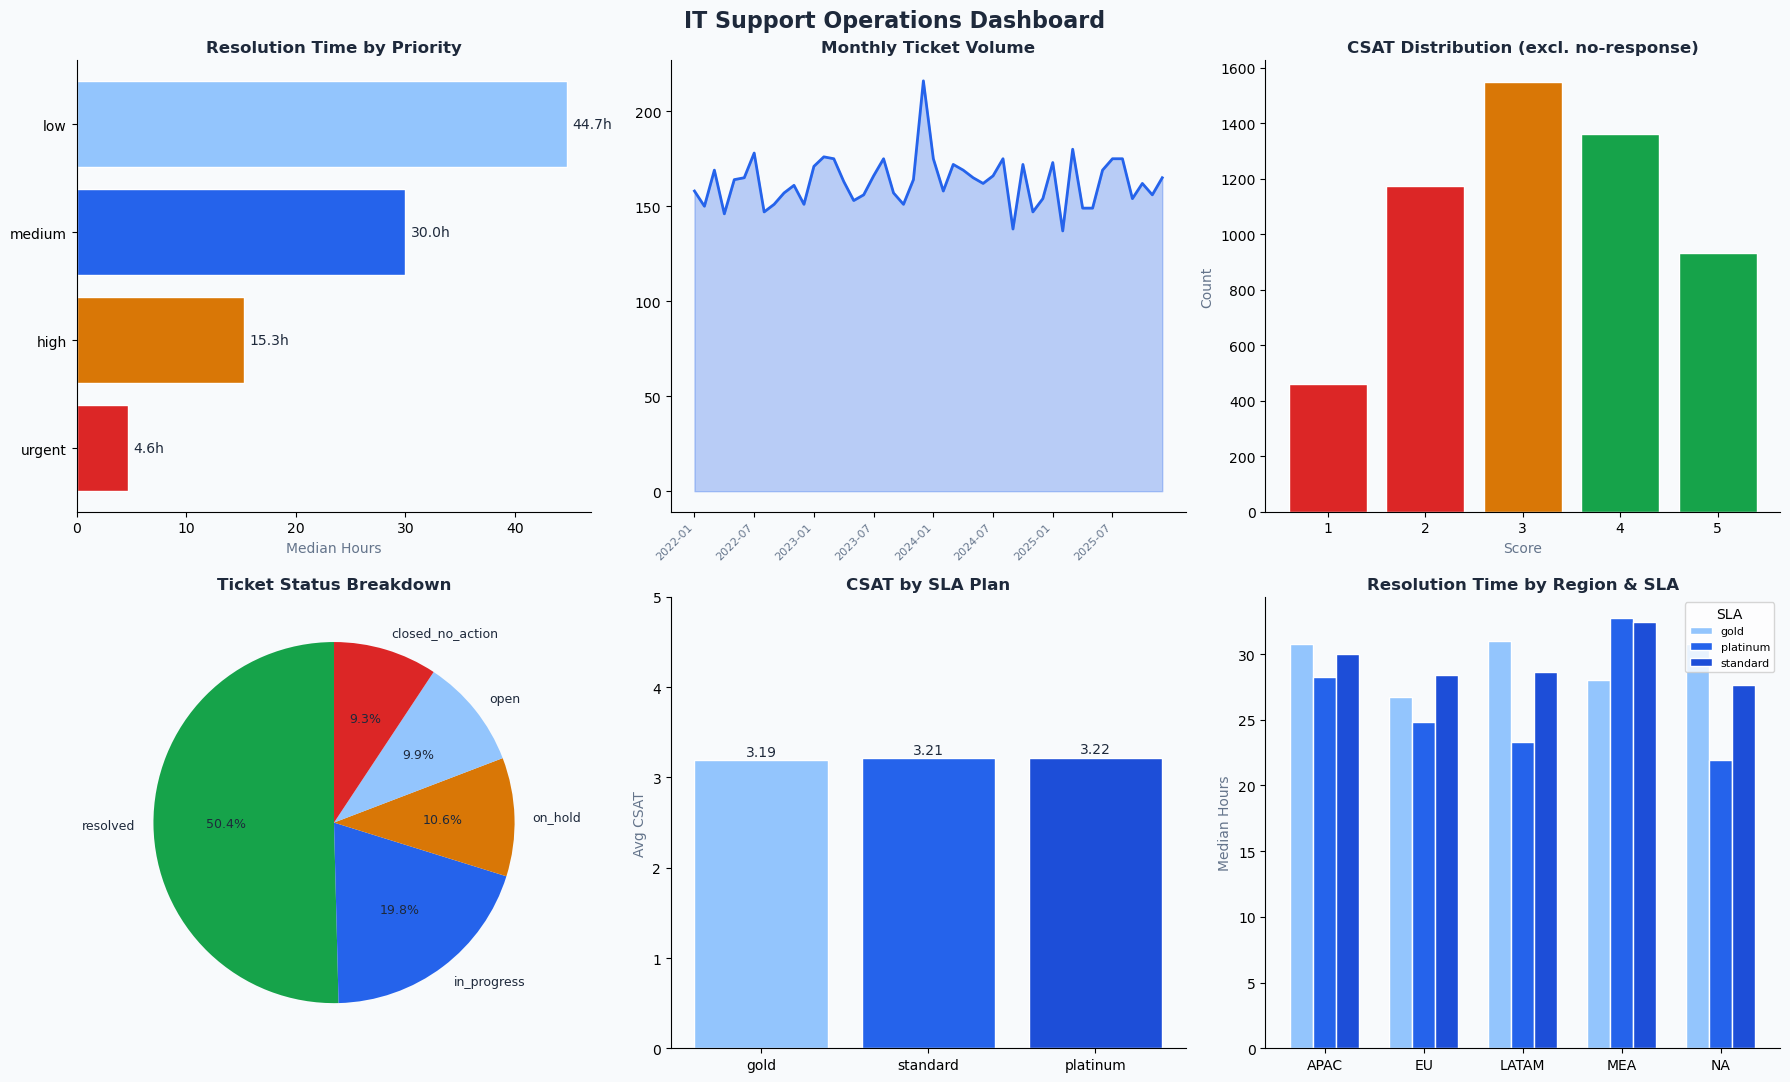

Figure 1 saved.


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor(BG)
fig.suptitle("IT Support Operations Dashboard", fontsize=16, fontweight="bold", color=DARK)

# Panel 1: Resolution time by priority
ax = axes[0, 0]
bars = ax.barh(priority_res["priority"], priority_res["median_hours"],
               color=[RED, AMBER, BLUE, LIGHT_BLUE], edgecolor="white")
for bar, val in zip(bars, priority_res["median_hours"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}h", va="center", color=DARK)
ax.set_title("Resolution Time by Priority", fontweight="bold", color=DARK)
ax.set_xlabel("Median Hours", color=GRAY)
ax.set_facecolor(BG); ax.spines[["top","right"]].set_visible(False)

# Panel 2: Monthly ticket volume
ax = axes[0, 1]
x = range(len(monthly))
ax.fill_between(x, monthly["n_tickets"], alpha=0.3, color=BLUE)
ax.plot(x, monthly["n_tickets"], color=BLUE, linewidth=2)
ticks = [i for i in x if i % 6 == 0]
ax.set_xticks(ticks)
ax.set_xticklabels([monthly["year_month"].iloc[i] for i in ticks],
                   rotation=45, ha="right", fontsize=8, color=GRAY)
ax.set_title("Monthly Ticket Volume", fontweight="bold", color=DARK)
ax.set_facecolor(BG); ax.spines[["top","right"]].set_visible(False)

# Panel 3: CSAT distribution
ax = axes[0, 2]
ax.bar(csat_dist["csat_score"], csat_dist["count"],
       color=[RED, RED, AMBER, GREEN, GREEN], edgecolor="white")
ax.set_title("CSAT Distribution (excl. no-response)", fontweight="bold", color=DARK)
ax.set_xlabel("Score", color=GRAY); ax.set_ylabel("Count", color=GRAY)
ax.set_facecolor(BG); ax.spines[["top","right"]].set_visible(False)

# Panel 4: Status breakdown
ax = axes[1, 0]
ax.pie(status["count"], labels=status["status"], autopct="%1.1f%%",
       colors=[GREEN, BLUE, AMBER, LIGHT_BLUE, RED], startangle=90,
       textprops={"fontsize": 9, "color": DARK})
ax.set_title("Ticket Status Breakdown", fontweight="bold", color=DARK)

# Panel 5: CSAT by SLA plan
ax = axes[1, 1]
ax.bar(csat_sla["sla_plan"], csat_sla["csat_score"],
       color=[LIGHT_BLUE, BLUE, NAVY], edgecolor="white")
ax.set_ylim(0, 5); ax.set_ylabel("Avg CSAT", color=GRAY)
ax.set_title("CSAT by SLA Plan", fontweight="bold", color=DARK)
for i, val in enumerate(csat_sla["csat_score"]):
    ax.text(i, val + 0.05, f"{val:.2f}", ha="center", color=DARK)
ax.set_facecolor(BG); ax.spines[["top","right"]].set_visible(False)

# Panel 6: Resolution time by region & SLA
ax = axes[1, 2]
region_sla.set_index("region").plot(kind="bar", ax=ax,
    color=[LIGHT_BLUE, BLUE, NAVY], edgecolor="white", width=0.7)
ax.set_title("Resolution Time by Region & SLA", fontweight="bold", color=DARK)
ax.set_ylabel("Median Hours", color=GRAY); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0); ax.legend(title="SLA", fontsize=8)
ax.set_facecolor(BG); ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figure1_dashboard.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Figure 1 saved.")

## Figure 2 — Resolution Time Distribution by Priority

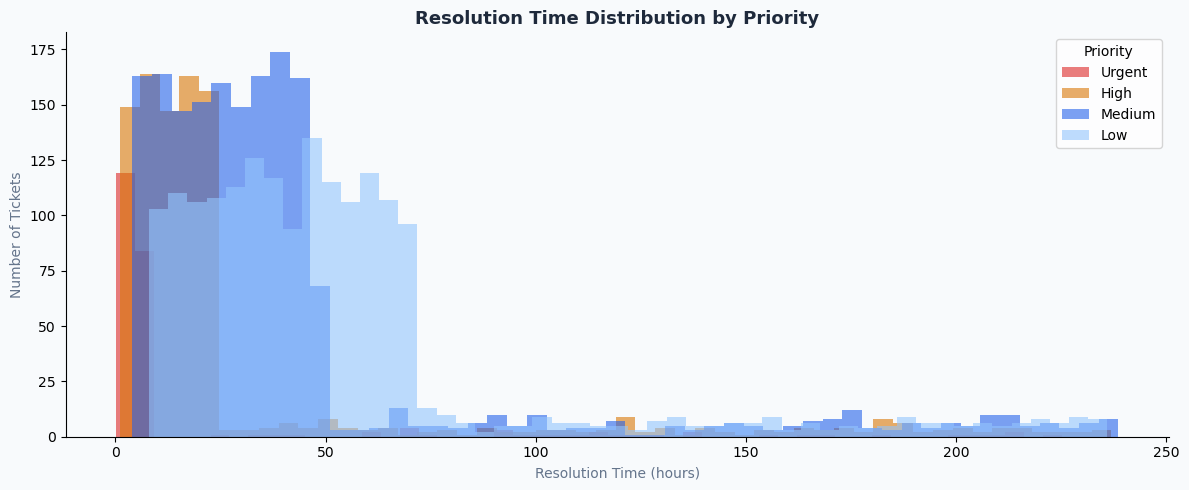

Figure 2 saved.


In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

for priority, color in zip(["urgent","high","medium","low"], [RED, AMBER, BLUE, LIGHT_BLUE]):
    data = resolved[resolved["priority"] == priority]["resolution_time_hours"]
    ax.hist(data, bins=50, alpha=0.6, label=priority.capitalize(), color=color, edgecolor="none")

ax.set_xlabel("Resolution Time (hours)", color=GRAY)
ax.set_ylabel("Number of Tickets", color=GRAY)
ax.set_title("Resolution Time Distribution by Priority", fontsize=13, fontweight="bold", color=DARK)
ax.spines[["top","right"]].set_visible(False)
ax.legend(title="Priority")
plt.tight_layout()
plt.savefig("figure2_resolution_dist.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Figure 2 saved.")

## Figure 3 — Ticket Volume by Channel and Issue Type

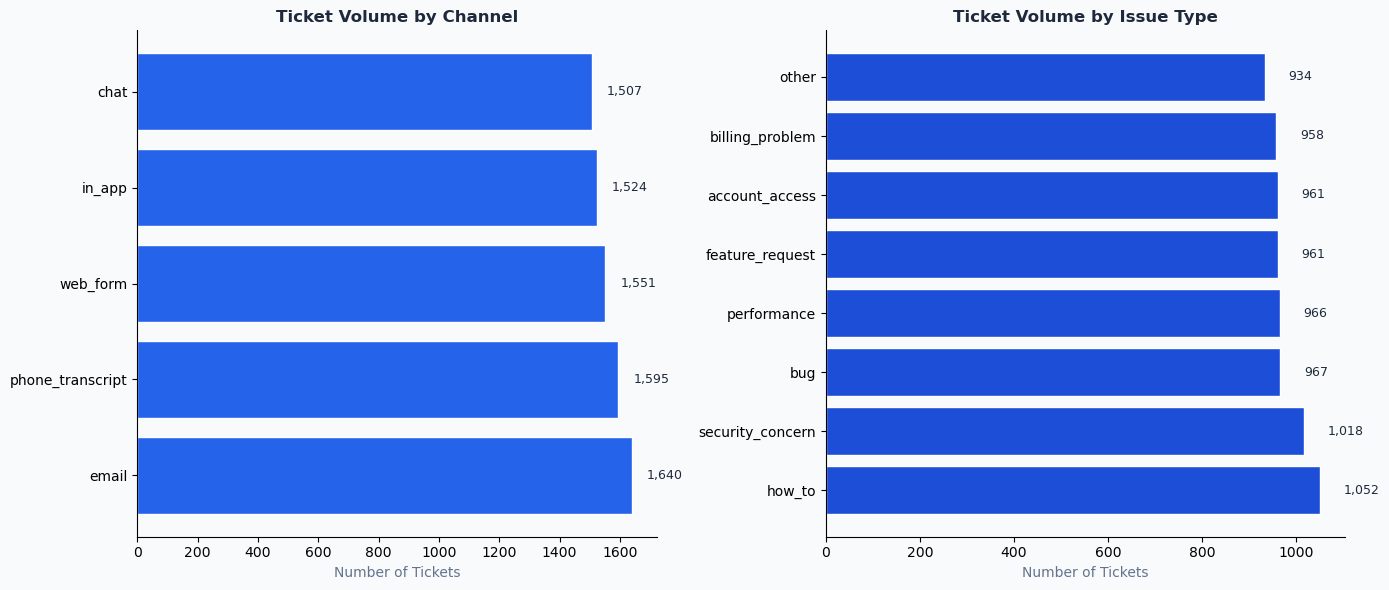

Figure 3 saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

axes[0].barh(channel["channel"], channel["count"], color=BLUE, edgecolor="white")
for i, val in enumerate(channel["count"]):
    axes[0].text(val + 50, i, f"{val:,}", va="center", fontsize=9, color=DARK)
axes[0].set_title("Ticket Volume by Channel", fontweight="bold", color=DARK)
axes[0].set_xlabel("Number of Tickets", color=GRAY)
axes[0].set_facecolor(BG); axes[0].spines[["top","right"]].set_visible(False)

axes[1].barh(issue_type["issue_type"], issue_type["count"], color=NAVY, edgecolor="white")
for i, val in enumerate(issue_type["count"]):
    axes[1].text(val + 50, i, f"{val:,}", va="center", fontsize=9, color=DARK)
axes[1].set_title("Ticket Volume by Issue Type", fontweight="bold", color=DARK)
axes[1].set_xlabel("Number of Tickets", color=GRAY)
axes[1].set_facecolor(BG); axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figure3_channel_issue.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Figure 3 saved.")

## Figure 4 — Ticket Volume by Product Area

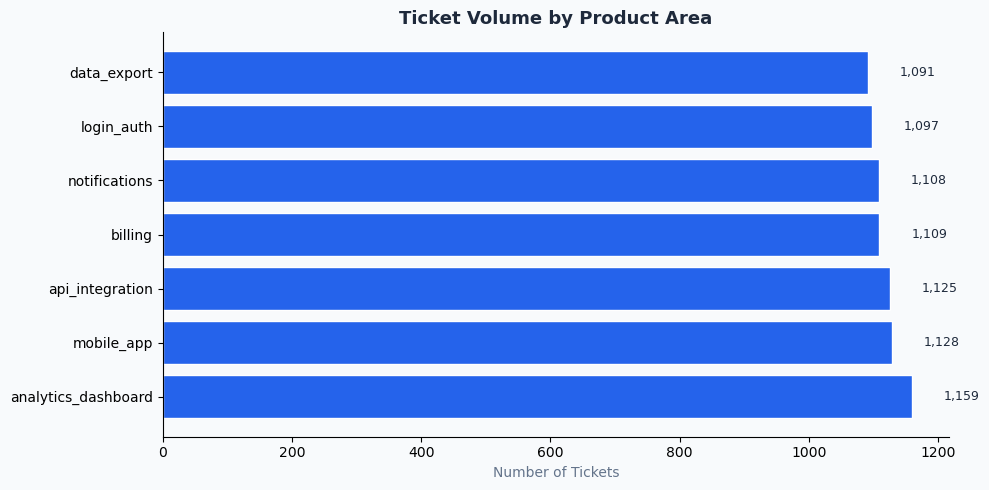

Figure 4 saved.


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

ax.barh(product_area["product_area"], product_area["count"], color=BLUE, edgecolor="white")
for i, val in enumerate(product_area["count"]):
    ax.text(val + 50, i, f"{val:,}", va="center", fontsize=9, color=DARK)

ax.set_title("Ticket Volume by Product Area", fontsize=13, fontweight="bold", color=DARK)
ax.set_xlabel("Number of Tickets", color=GRAY)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figure4_product_area.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Figure 4 saved.")

## Figure 5 — Customer Sentiment Distribution

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

colors = [RED, AMBER, GRAY, LIGHT_BLUE, GREEN]
ax.bar(sentiment["customer_sentiment"], sentiment["count"],
       color=colors, edgecolor="white")
ax.set_title("Customer Sentiment Distribution", fontsize=13, fontweight="bold", color=DARK)
ax.set_xlabel("Sentiment", color=GRAY)
ax.set_ylabel("Number of Tickets", color=GRAY)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figure5_sentiment.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Figure 5 saved.")

## Figure 6 — Average CSAT by Customer Segment and Region

In [ ]:
pivot = csat_heatmap.set_index("customer_segment")

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues",
            linewidths=0.5, ax=ax, vmin=2.5, vmax=4,
            cbar_kws={"label": "Avg CSAT"})
ax.set_title("Average CSAT by Customer Segment & Region",
             fontsize=13, fontweight="bold", color=DARK)
ax.set_xlabel("Region", color=GRAY)
ax.set_ylabel("Customer Segment", color=GRAY)
plt.tight_layout()
plt.savefig("figure6_csat_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 6 saved.")

## Figure 7 — CSAT and Reopen Rate by Issue Type

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

axes[0].barh(issue_stats["issue_type"], issue_stats["avg_csat"],
             color=BLUE, edgecolor="white")
axes[0].set_xlim(0, 5)
axes[0].set_title("Average CSAT by Issue Type", fontweight="bold", color=DARK)
axes[0].set_xlabel("Avg CSAT Score", color=GRAY)
axes[0].set_facecolor(BG); axes[0].spines[["top","right"]].set_visible(False)

axes[1].barh(issue_stats["issue_type"], issue_stats["reopen_rate"] * 100,
             color=AMBER, edgecolor="white")
axes[1].set_title("Reopen Rate by Issue Type (%)", fontweight="bold", color=DARK)
axes[1].set_xlabel("Reopen Rate (%)", color=GRAY)
axes[1].set_facecolor(BG); axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figure7_csat_reopen.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Figure 7 saved.")